# 03. Продуктовые метрики и воронка

Задача ноутбука — определить этапы клиентского пути, на которых происходят основные потери между первым и вторым курсом, и выявить сегменты с наибольшим потенциалом роста повторных продаж.

Расчёты выполняются по всей когорте 2024 года, включая индивидуальный формат обучения: на данном этапе рассматривается бизнес в целом, а не подвыборка, пригодная для моделирования.

**Ограничение.** Выгрузка не содержит денежных показателей — ни стоимости курса, ни сумм платежей. Расчёт ARPU, LTV и выручки в связи с этим невозможен, все метрики выражены в клиентах и конверсиях.

In [1]:
import sqlite3
from contextlib import closing

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

DB_PATH = '../data/churn.db'
DATE_COLUMNS = ['first_course_start_date', 'first_course_end_date',
                'group_churn_date', 'second_course_payment_date']

sns.set_theme(style='whitegrid', rc={'font.family': 'DejaVu Sans'})


def load_table(name):
    with closing(sqlite3.connect(DB_PATH)) as conn:
        frame = pd.read_sql_query(f'SELECT * FROM {name}', conn)
    for column in [c for c in DATE_COLUMNS if c in frame.columns]:
        frame[column] = pd.to_datetime(frame[column])
    return frame


df = load_table('students_clean')
df['dropped_out'] = df['dropped_out'].astype(bool)
df['bought_second'] = df['bought_second'].astype(bool)
df['bought_before_course_end'] = df['bought_before_course_end'].astype(bool)

print(f'Когорта: {len(df):,} студентов, старт первого курса в 2024 году')

Когорта: 6,568 студентов, старт первого курса в 2024 году


## Воронка первого курса

In [2]:
total = len(df)
completed = int((~df['dropped_out']).sum())
bought = int(df['bought_second'].sum())

funnel = pd.DataFrame({
    'Этап': ['Начал первый курс', 'Доучился до конца', 'Купил второй курс'],
    'Студентов': [total, completed, bought],
})
funnel['Доля от когорты, %'] = (funnel['Студентов'] / total * 100).round(1)

display(funnel)

crosstab = pd.crosstab(
    df['dropped_out'].map({False: 'доучился', True: 'ушёл из группы'}),
    df['bought_second'].map({False: 'не купил', True: 'купил второй курс'}),
    margins=True, margins_name='всего')

display(crosstab)

,Этап,Студентов,"Доля от когорты, %"
0,Начал первый курс,6568,100.0
1,Доучился до конца,3124,47.6
2,Купил второй курс,2118,32.2


bought_second,купил второй курс,не купил,всего
dropped_out,,,
доучился,1314,1810,3124
ушёл из группы,804,2640,3444
всего,2118,4450,6568


### Половина когорты не завершает первый курс

Из 6 568 учеников первый курс завершают 3 124 человека — менее половины когорты. Второй курс приобретают 2 118 человек, что соответствует конверсии 32.2%.

Воронка не является строго вложенной, что подтверждается таблицей сопряжённости: 804 ученика выбыли из группы, но впоследствии приобрели второй курс. Выбытие не исключает повторную покупку, однако существенно снижает её вероятность — 23.3% против 42.1% у завершивших обучение. Данное обстоятельство имеет значение для дальнейшего анализа: выбытие не может рассматриваться как конкурирующее событие, исключающее покупку.

## Ключевые метрики

In [3]:
metrics = pd.Series({
    'Студентов в когорте': f'{total:,}',
    'Отвал с первого курса': f'{df["dropped_out"].mean() * 100:.1f}%',
    'Дошли до конца первого курса': f'{(~df["dropped_out"]).mean() * 100:.1f}%',
    'Конверсия во второй курс': f'{df["bought_second"].mean() * 100:.1f}%',
    'Конверсия среди доучившихся': f'{df.loc[~df["dropped_out"], "bought_second"].mean() * 100:.1f}%',
    'Конверсия среди ушедших': f'{df.loc[df["dropped_out"], "bought_second"].mean() * 100:.1f}%',
    'Покупок до окончания первого курса': f'{df["bought_before_course_end"].sum() / bought * 100:.1f}%',
    'Медиана до ухода из группы, дней': f'{df["days_to_dropout"].median():.0f}',
    'Медиана до второй покупки, дней': f'{df["days_to_second"].median():.0f}',
    'Медианная длительность курса, дней': f'{df["course_duration_days"].median():.0f}',
}, name='значение').to_frame()

display(metrics)

,значение
Студентов в когорте,"6,568"
Отвал с первого курса,52.4%
Дошли до конца первого курса,47.6%
Конверсия во второй курс,32.2%
Конверсия среди доучившихся,42.1%
Конверсия среди ушедших,23.3%
Покупок до окончания первого курса,76.0%
"Медиана до ухода из группы, дней",56
"Медиана до второй покупки, дней",100
"Медианная длительность курса, дней",224


### Локализация потерь

Доля выбывших с первого курса составляет 52.4%, медиана времени до выбытия — 56 дней при медианной длительности курса 224 дня. Половина выбывших прекращает обучение, пройдя около четверти программы. Это наиболее крупная потеря в воронке, происходящая задолго до момента, когда возникает вопрос о приобретении второго курса.

Второй результат: 76% повторных покупок совершаются до завершения первого курса, медиана времени до покупки составляет 100 дней при длительности курса 224 дня.

Здесь требуется оговорка. Выгрузка содержит только даты платежей и не содержит данных о работе отдела продаж, поэтому распределение покупок во времени отражает совокупный результат двух процессов — готовности клиента и графика контактов менеджеров. Разделить их на имеющихся данных невозможно, и утверждение ограничивается наблюдаемым фактом: к моменту завершения курса большинство повторных покупок уже совершено.

## Распределение повторных покупок во времени

In [4]:
horizons = [30, 60, 90, 120, 180, 240, 365]
retention = pd.DataFrame({
    'Дней от старта курса': horizons,
    'Купили второй курс': [int((df['days_to_second'] <= h).sum()) for h in horizons],
})
retention['Доля когорты, %'] = (retention['Купили второй курс'] / total * 100).round(1)
retention['Доля всех покупок, %'] = (retention['Купили второй курс'] / bought * 100).round(1)

display(retention)

,Дней от старта курса,Купили второй курс,"Доля когорты, %","Доля всех покупок, %"
0,30,408,6.2,19.3
1,60,899,13.7,42.4
2,90,1044,15.9,49.3
3,120,1129,17.2,53.3
4,180,1395,21.2,65.9
5,240,1741,26.5,82.2
6,365,1940,29.5,91.6


### Основной объём покупок приходится на первые три месяца

К шестидесятому дню от начала обучения совершено 42.4% всех повторных покупок, к девяностому — 49.3%. Далее динамика замедляется: за период с 240-го по 365-й день добавляется около девяти процентов покупок.

Практическое следствие: период, в течение которого повторная покупка вообще происходит, приходится на первые два-три месяца обучения — то есть совпадает с периодом основного выбытия с курса.

## Динамика после завершения курса

In [5]:
after_end = df.loc[df['first_course_end_date'].notna()].copy()
not_bought_by_end = ~after_end['bought_before_course_end']

windows = [0, 30, 60, 90, 120]
late_conversion = []
for window in windows:
    still_waiting = not_bought_by_end & (~after_end['bought_second']
                                         | (after_end['days_after_course_end'] > window))
    will_buy = still_waiting & after_end['bought_second']
    late_conversion.append({
        'Дней после конца курса': window,
        'Ещё не купили': int(still_waiting.sum()),
        'Из них купят позже': int(will_buy.sum()),
        'Шанс покупки, %': round(will_buy.sum() / still_waiting.sum() * 100, 2),
    })

display(pd.DataFrame(late_conversion))

,Дней после конца курса,Ещё не купили,Из них купят позже,"Шанс покупки, %"
0,0,4958,508,10.25
1,30,4772,322,6.75
2,60,4716,266,5.64
3,90,4683,233,4.98
4,120,4655,205,4.40


### Вероятность покупки после завершения курса

Таблица отвечает на прикладной вопрос: если по истечении N дней после завершения курса покупка не совершена, какова вероятность её последующего наступления.

На момент завершения курса вероятность составляет 10.25%, через месяц — 6.75%, через два месяца — 5.64%, через четыре — 4.40%.

В измеренных точках снижение монотонное. Более дробная сетка не рассматривалась, поэтому по данной таблице нельзя судить о наличии или отсутствии порогового значения внутри интервалов — для такого вывода потребовалась бы оценка риска возврата по коротким окнам.

Что таблица показывает определённо: уже на момент завершения курса вероятность повторной покупки составляет около 10%. Мероприятия по удержанию, запускаемые после выпуска, работают с той частью базы, где потенциал изначально невелик.

## Когортный анализ

In [6]:
COMPARABLE_HORIZON = 365

print(f"Минимум наблюдения по когорте: {df['observed_days'].min()} дней, "
      f'поэтому горизонт {COMPARABLE_HORIZON} дней доступен всем')

cohorts = df.assign(
    cohort_month=df['first_course_start_date'].dt.to_period('M').astype(str),
    bought_within_horizon=df['bought_second'] & (df['days_to_second'] <= COMPARABLE_HORIZON),
).groupby('cohort_month').agg(
    students=('id', 'size'),
    dropout_pct=('dropped_out', lambda s: s.mean() * 100),
    repeat_pct=('bought_second', lambda s: s.mean() * 100),
    repeat_365_pct=('bought_within_horizon', lambda s: s.mean() * 100),
    median_days_to_second=('days_to_second', 'median'),
).round(1).reset_index()

display(cohorts)

Минимум наблюдения по когорте: 428 дней, поэтому горизонт 365 дней доступен всем


,cohort_month,students,dropout_pct,repeat_pct,repeat_365_pct,median_days_to_second
0,2024-01,260,59.2,40.0,38.5,109.0
1,2024-02,494,57.3,44.3,40.7,105.0
2,2024-03,556,55.9,37.2,36.0,100.0
3,2024-04,519,64.2,39.7,37.4,77.5
4,2024-05,615,55.1,43.4,40.8,50.0
5,2024-06,549,56.8,28.1,24.2,111.0
6,2024-07,522,53.8,22.0,16.5,207.0
7,2024-08,490,51.2,22.7,18.0,173.0
8,2024-09,795,41.1,34.5,32.3,102.0
9,2024-10,647,50.4,30.3,28.1,55.5


### Снижение конверсии в течение года подтверждается

Прямое сравнение когорт некорректно: декабрьская когорта располагает меньшим временем для совершения покупки, чем январская, и уступит ей вследствие усечённого периода наблюдения. Для устранения этого эффекта рядом с общей конверсией приводится конверсия за фиксированный период в 365 дней; минимальная длительность наблюдения по когорте составляет 428 дней, следовательно, данный горизонт доступен для всех когорт.

На сопоставимом горизонте снижение сохраняется: когорты января–мая демонстрируют 36–41%, июня–августа — 16–24%, сентябрь частично восстанавливает показатель до 32.3%, декабрь — 17.3%.

При этом доля выбывших с первого курса за год снизилась с 59% в январе до 46–48% в ноябре–декабре. Удержание в рамках первого курса улучшилось, тогда как результативность повторных продаж снизилась. Это два самостоятельных процесса, требующих различных управленческих решений.

## Сегментный анализ

In [7]:
def segment_metrics(dimension):
    segment = df.groupby(dimension, observed=True).agg(
        students=('id', 'size'),
        dropout_pct=('dropped_out', lambda s: s.mean() * 100),
        repeat_pct=('bought_second', lambda s: s.mean() * 100),
        median_days_to_second=('days_to_second', 'median'),
    ).round(1)
    segment['share_pct'] = (segment['students'] / len(df) * 100).round(1)
    return segment.sort_values('students', ascending=False).reset_index()


df['age_band'] = pd.cut(df['age'], [4, 7, 10, 13, 17],
                        labels=['5-7', '8-10', '11-13', '14-17'])

by_format = segment_metrics('course_format_group')
by_payment = segment_metrics('payment_type_group')
by_channel = segment_metrics('utm_source_group')
by_age = segment_metrics('age_band')

display(by_format, by_payment, by_channel, by_age)

,course_format_group,students,dropout_pct,repeat_pct,median_days_to_second,share_pct
0,premium,3406,57.5,29.9,118.0,51.9
1,standard,2509,45.9,37.2,102.5,38.2
2,individual,653,51.1,25.3,56.0,9.9


,payment_type_group,students,dropout_pct,repeat_pct,median_days_to_second,share_pct
0,full,2971,60.4,33.5,87.0,45.2
1,bank_installment,2181,40.4,22.6,218.0,33.2
2,internal_installment,1416,54.2,44.6,34.0,21.6


,utm_source_group,students,dropout_pct,repeat_pct,median_days_to_second,share_pct
0,meta,2551,58.0,32.9,67.0,38.8
1,referral,1483,45.9,30.3,171.0,22.6
2,yandex,715,54.8,29.8,91.0,10.9
3,other,693,53.4,33.6,107.0,10.6
4,vk,473,43.3,29.4,134.0,7.2
5,whatsapp,199,49.7,34.2,61.0,3.0
6,website,185,38.4,45.9,107.0,2.8
7,social,144,56.2,38.2,117.0,2.2
8,influencer,60,61.7,36.7,128.5,0.9
9,telegram,58,48.3,20.7,50.0,0.9


,age_band,students,dropout_pct,repeat_pct,median_days_to_second,share_pct
0,8-10,2568,58.5,29.9,106.0,39.1
1,11-13,2303,47.8,36.2,107.0,35.1
2,14-17,1057,37.7,36.0,77.0,16.1
3,5-7,640,69.1,21.6,101.5,9.7


### Банковская рассрочка формирует наиболее проблемный сегмент

Различия по типу оплаты значительны: внутренняя рассрочка соответствует конверсии 44.6%, полная оплата — 33.5%, банковская рассрочка — 22.6%.

Более информативным показателем выступает скорость повторной покупки. Медиана времени до неё составляет: внутренняя рассрочка — 34 дня, полная оплата — 87 дней, банковская рассрочка — 218 дней. Различие шестикратное.

Правдоподобное объяснение — действующее кредитное обязательство за первый курс: пока оно не закрыто, вторая покупка означает второй кредит. Проверить это на имеющихся данных нельзя: выгрузка не содержит ни суммы рассрочки, ни её срока, ни графика платежей. Объяснение остаётся гипотезой и требует отдельной выгрузки из платёжной системы.

Что утверждается по данным: сегмент крупный — 2 181 ученик, треть когорты, — и он одновременно худший по конверсии и самый медленный по скорости повторной покупки.

По формату обучения премиальные группы демонстрируют конверсию 29.9% против 37.2% у стандартных при более высокой стоимости и доле в половину когорты.

## Проверка статистической значимости

In [8]:
contingency = pd.crosstab(df['payment_type_group'], df['bought_second'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print('Хи-квадрат: связан ли тип оплаты с покупкой второго курса')
print(f'chi2 = {chi2:.1f}, степеней свободы = {dof}, p-value = {p_value:.3e}')
print('Вывод: связь есть' if p_value < 0.05 else 'Вывод: связи нет')

display(contingency)

Хи-квадрат: связан ли тип оплаты с покупкой второго курса
chi2 = 194.1, степеней свободы = 2, p-value = 7.114e-43
Вывод: связь есть


bought_second,False,True
payment_type_group,,
bank_installment,1689,492
full,1976,995
internal_installment,785,631


Связь типа оплаты с повторной покупкой статистически значима со значительным запасом. Критерий хи-квадрат применён на основании характера данных: обе переменные категориальные, группы независимы, ожидаемые частоты во всех ячейках превышают пять.

Это единственная процедура проверки гипотез в данном ноутбуке. Прочие различия либо очевидны по величине, либо проверяются в ноутбуке 05 методами, корректными для цензурированных наблюдений.

## Оценка потенциала сегментов

In [9]:
BENCHMARK = df['bought_second'].mean() * 100

growth = []
for dimension, table in [('формат', by_format), ('тип оплаты', by_payment),
                         ('канал', by_channel), ('возраст', by_age)]:
    for _, row in table.iterrows():
        gap = BENCHMARK - row['repeat_pct']
        if gap > 0:
            growth.append({
                'Разрез': dimension,
                'Сегмент': str(row.iloc[0]),
                'Студентов': int(row['students']),
                'Конверсия, %': row['repeat_pct'],
                'Отставание от среднего, п.п.': round(gap, 1),
                'Потенциал, доп. покупок': int(round(row['students'] * gap / 100)),
            })

growth_points = pd.DataFrame(growth).sort_values('Потенциал, доп. покупок', ascending=False)

print(f'Средняя конверсия по когорте: {BENCHMARK:.1f}%')
display(growth_points.head(12).reset_index(drop=True))

Средняя конверсия по когорте: 32.2%


,Разрез,Сегмент,Студентов,"Конверсия, %","Отставание от среднего, п.п.","Потенциал, доп. покупок"
0,тип оплаты,bank_installment,2181,22.6,9.6,210
1,формат,premium,3406,29.9,2.3,80
2,возраст,5-7,640,21.6,10.6,68
3,возраст,8-10,2568,29.9,2.3,60
4,формат,individual,653,25.3,6.9,45
5,канал,referral,1483,30.3,1.9,29
6,канал,yandex,715,29.8,2.4,17
7,канал,vk,473,29.4,2.8,13
8,канал,telegram,58,20.7,11.5,7
9,канал,content,7,28.6,3.6,0


### Приоритизация по абсолютному потенциалу

Потенциал сегмента рассчитывается как число дополнительных повторных покупок при условии достижения сегментом средней конверсии по когорте (32.2%). Такой подход обеспечивает приоритет крупному сегменту с умеренным отставанием перед малочисленным сегментом с существенным отставанием, что соответствует ограниченности ресурсов подразделения продаж.

Полученная приоритизация:

1. **Банковская рассрочка** — 2 181 ученик, отставание 9.6 п.п., потенциал 210 дополнительных покупок.
2. **Премиальный формат** — 3 406 учеников, отставание 2.3 п.п., что за счёт численности сегмента соответствует 80 покупкам.
3. **Возрастная группа 5–7 лет** — 640 учеников, отставание 10.6 п.п., потенциал 68 покупок.

**Оценки не суммируются.** Сегменты пересекаются: ученик может одновременно относиться к премиальному формату, оплачивать обучение банковской рассрочкой и попадать в младшую возрастную группу. Каждое значение следует читать по отдельности, как оценку по одному направлению.

Кроме того, расчёт исходит из допущения, что отставание сегмента устранимо. Проверки этого допущения он не содержит: если различие обусловлено характеристиками аудитории, а не работой с ней, потенциал окажется недостижимым.

## Сводная визуализация

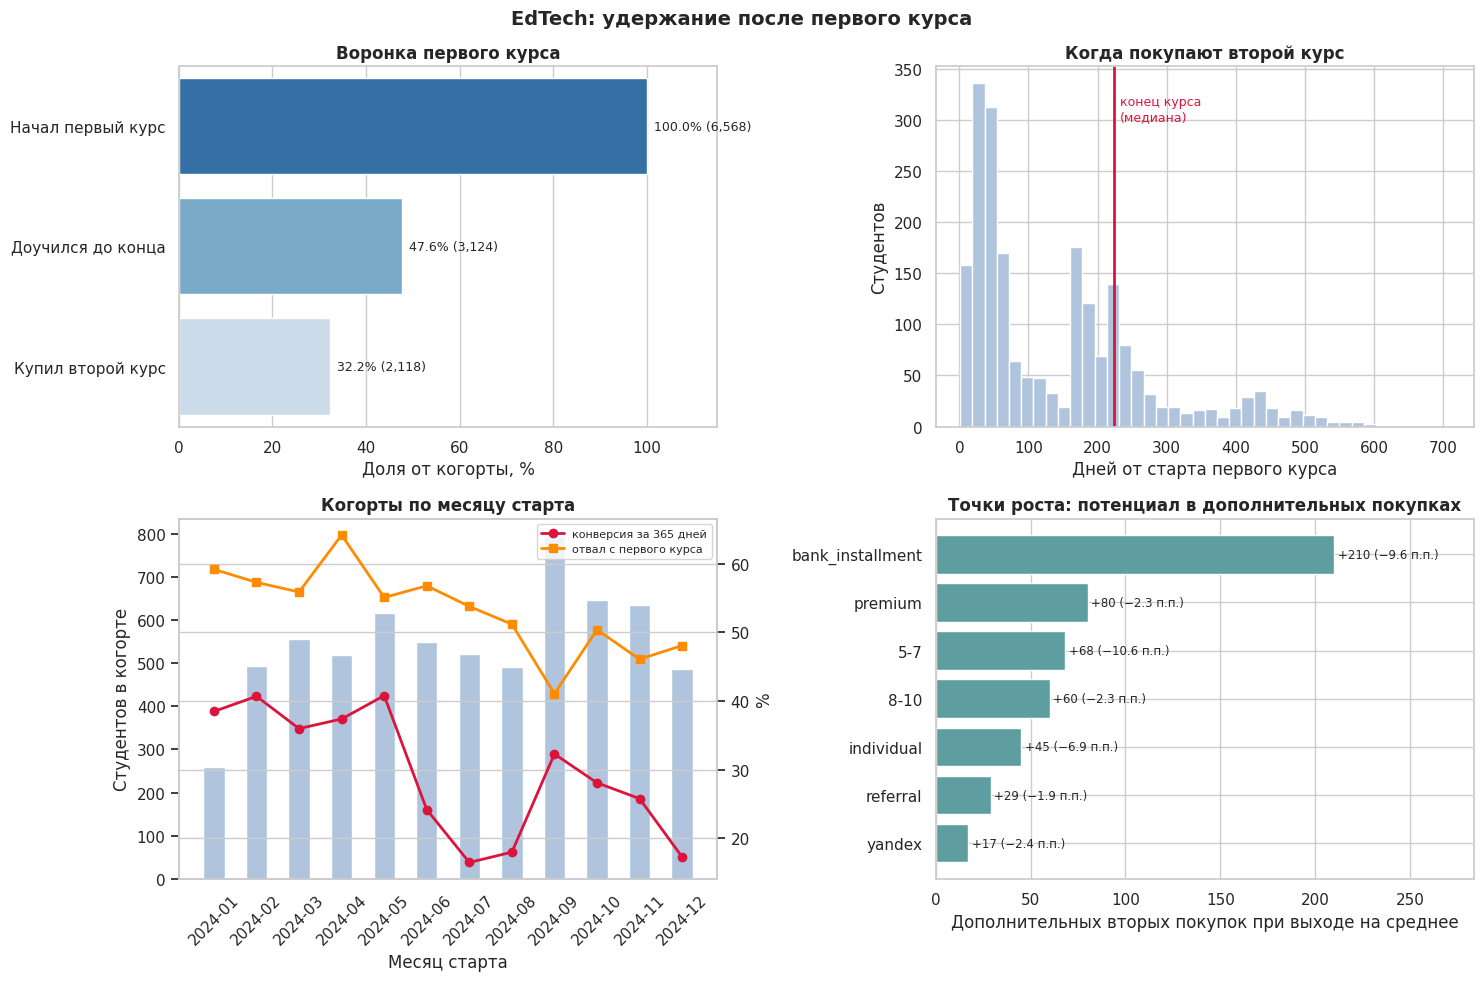

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('EdTech: удержание после первого курса', fontsize=14, fontweight='bold', y=0.98)

sns.barplot(data=funnel, x='Доля от когорты, %', y='Этап', ax=axes[0, 0],
            hue='Этап', palette='Blues_r', legend=False)
axes[0, 0].set_title('Воронка первого курса', fontweight='bold')
axes[0, 0].set_ylabel('')
axes[0, 0].set_xlim(0, 115)
for position, (share, count) in enumerate(zip(funnel['Доля от когорты, %'], funnel['Студентов'])):
    axes[0, 0].text(share + 1.5, position, f'{share}% ({count:,})', va='center', fontsize=9)

buyers = df.loc[df['bought_second'], 'days_to_second']
axes[0, 1].hist(buyers, bins=40, color='lightsteelblue', edgecolor='white')
axes[0, 1].axvline(df['course_duration_days'].median(), color='crimson', linewidth=2)
axes[0, 1].text(df['course_duration_days'].median() + 8, axes[0, 1].get_ylim()[1] * 0.85,
                'конец курса\n(медиана)', color='crimson', fontsize=9)
axes[0, 1].set_title('Когда покупают второй курс', fontweight='bold')
axes[0, 1].set_xlabel('Дней от старта первого курса')
axes[0, 1].set_ylabel('Студентов')

cohort_axis = axes[1, 0]
cohort_axis.bar(cohorts['cohort_month'], cohorts['students'], color='lightsteelblue', width=0.5)
cohort_axis.set_ylabel('Студентов в когорте')
cohort_axis.set_xlabel('Месяц старта')
cohort_axis.tick_params(axis='x', rotation=45)
cohort_axis.grid(False)

conversion_axis = cohort_axis.twinx()
conversion_axis.plot(cohorts['cohort_month'], cohorts['repeat_365_pct'],
                     color='crimson', marker='o', linewidth=2, label='конверсия за 365 дней')
conversion_axis.plot(cohorts['cohort_month'], cohorts['dropout_pct'],
                     color='darkorange', marker='s', linewidth=2, label='отвал с первого курса')
conversion_axis.set_ylabel('%')
conversion_axis.legend(fontsize=8, loc='upper right')
cohort_axis.set_title('Когорты по месяцу старта', fontweight='bold')

top_growth = growth_points.head(7).iloc[::-1]
axes[1, 1].barh(top_growth['Сегмент'], top_growth['Потенциал, доп. покупок'], color='cadetblue')
axes[1, 1].set_title('Точки роста: потенциал в дополнительных покупках', fontweight='bold')
axes[1, 1].set_xlabel('Дополнительных вторых покупок при выходе на среднее')
for position, (segment, potential, gap) in enumerate(
        zip(top_growth['Сегмент'], top_growth['Потенциал, доп. покупок'],
            top_growth['Отставание от среднего, п.п.'])):
    axes[1, 1].text(potential + 2, position, f'+{potential} (−{gap} п.п.)', va='center', fontsize=8.5)
axes[1, 1].set_xlim(0, top_growth['Потенциал, доп. покупок'].max() * 1.35)

plt.tight_layout()
plt.show()

## Выводы

1. **Основные потери приходятся на первый курс, а не на этап повторной продажи.** Доля выбывших составляет 52.4%, медиана выбытия — 56-й день из 224. До момента, когда возникает вопрос о продолжении обучения, половина когорты утрачена.
2. **Большая часть повторных покупок совершается до завершения курса** — 76%, к 90-му дню зафиксировано 49.3% всех покупок. После завершения курса вероятность покупки составляет около 10% и далее снижается.
3. **Банковская рассрочка — крупнейший проблемный сегмент.** Треть когорты, конверсия 22.6% против 44.6% у внутренней рассрочки, медиана времени до покупки 218 дней против 34. Объяснение через действующее кредитное обязательство правдоподобно, но на имеющихся данных не проверяется.
4. **Конверсия снижалась в течение года** и на сопоставимом горизонте наблюдения, тогда как удержание в рамках первого курса улучшалось. Факторы, объясняющие эту динамику, в выгрузке не отражены.

Дальнейший анализ: ноутбук 04 содержит модели риска для двух моментов управленческого воздействия, ноутбук 05 — анализ динамики обоих событий во времени.